# Clasificación de Perros y Gatos con un Perceptrón Multicapa (MLP)

**Asignatura:** TLY1101 – Técnicas Avanzadas de Machine Learning I
**Evaluación:** EP1 – Presentación y defensa técnica del proyecto
**Dataset:** Oxford-IIIT Pet Dataset (variante propia: clasificación binaria perro vs. gato)

## 1. Introducción

Este notebook implementa un **Perceptrón Multicapa (MLP)** para clasificar fotografías de mascotas en dos categorías: **perro** (etiqueta 0) y **gato** (etiqueta 1).

El dataset original tiene 7.349 imágenes en 37 razas. Como variante propia del grupo, se simplificó el problema a una clasificación binaria, usando una muestra balanceada de 1.600 imágenes por clase (3.200 en total), con semilla fija `SEED = 17` para que el experimento sea reproducible.

**Objetivo:** dada una fotografía, predecir si es un perro o un gato, evaluando el modelo con métricas estándar de clasificación (Accuracy, Precision, Recall, F1-Score, Matriz de Confusión) y analizando sus errores y limitaciones.

> El dataset corresponde a fotografías de mascotas de uso académico público (Parkhi et al., 2012), sin datos personales ni sensibles. El modelo se desarrolla con fines educativos.


In [1]:
import os
import shutil
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
IMAGES_DIR_DEFAULT = PROJECT_ROOT / 'data' / 'oxford_pets' / 'images'

def obtener_directorio_imagenes():
    # Usa el dataset local si ya existe; si no, lo descarga desde Kaggle.
    if IMAGES_DIR_DEFAULT.exists() and any(IMAGES_DIR_DEFAULT.glob('*.jpg')):
        print(f"Dataset local encontrado en: {IMAGES_DIR_DEFAULT.resolve()}")
        return IMAGES_DIR_DEFAULT

    print("Dataset local no encontrado. Descargando desde Kaggle...")
    import kagglehub
    ruta_descarga = Path(kagglehub.dataset_download("tanlikesmath/the-oxfordiiit-pet-dataset"))
    destino = PROJECT_ROOT / 'data' / 'oxford_pets'
    destino.mkdir(parents=True, exist_ok=True)
    shutil.copytree(ruta_descarga, destino, dirs_exist_ok=True)
    return destino / 'images'

IMAGES_DIR = obtener_directorio_imagenes()

RUTA_IMAGENES_SALIDA = PROJECT_ROOT / 'images'
RUTA_MODELOS = PROJECT_ROOT / 'models'
RUTA_IMAGENES_SALIDA.mkdir(parents=True, exist_ok=True)
RUTA_MODELOS.mkdir(parents=True, exist_ok=True)


Dataset local no encontrado. Descargando desde Kaggle...


ModuleNotFoundError: No module named 'kagglehub'

## 2. Comprensión y exploración del conjunto de datos (EDA)

Antes de preprocesar las imágenes, es importante entender qué contiene el dataset: cuántas imágenes hay disponibles por clase, cómo se ven, y qué dificultades visuales podrían afectar la clasificación.

In [2]:
import numpy as np
from PIL import Image
import random

# --- Configuración de la variante del proyecto ---
SEED = 17
IMG_SIZE = 64
N_PER_CLASS = 1600

random.seed(SEED)
np.random.seed(SEED)

# --- Definición de clases (perro=0, gato=1) según convención Oxford-IIIT ---
# El dataset nombra los archivos como "Raza_numero.jpg": si la raza empieza
# con mayúscula, es una raza de gato; si empieza con minúscula, es de perro.
def es_gato(filename):
    return filename[0].isupper()

def cargar_y_filtrar_dataset(images_dir, n_per_class=N_PER_CLASS, seed=SEED):
    todos = os.listdir(images_dir)
    gatos = [f for f in todos if f.lower().endswith(('.jpg', '.jpeg')) and es_gato(f)]
    perros = [f for f in todos if f.lower().endswith(('.jpg', '.jpeg')) and not es_gato(f)]

    print(f"Imágenes de gato disponibles en el dataset completo: {len(gatos)}")
    print(f"Imágenes de perro disponibles en el dataset completo: {len(perros)}")

    rng = random.Random(seed)
    gatos_sel = rng.sample(gatos, min(n_per_class, len(gatos)))
    perros_sel = rng.sample(perros, min(n_per_class, len(perros)))

    print(f"Imágenes de gato seleccionadas para el proyecto: {len(gatos_sel)}")
    print(f"Imágenes de perro seleccionadas para el proyecto: {len(perros_sel)}")

    return gatos_sel, perros_sel

gatos_sel, perros_sel = cargar_y_filtrar_dataset(IMAGES_DIR)


Imágenes de gato disponibles en el dataset completo: 2400
Imágenes de perro disponibles en el dataset completo: 4990
Imágenes de gato seleccionadas para el proyecto: 1600
Imágenes de perro seleccionadas para el proyecto: 1600


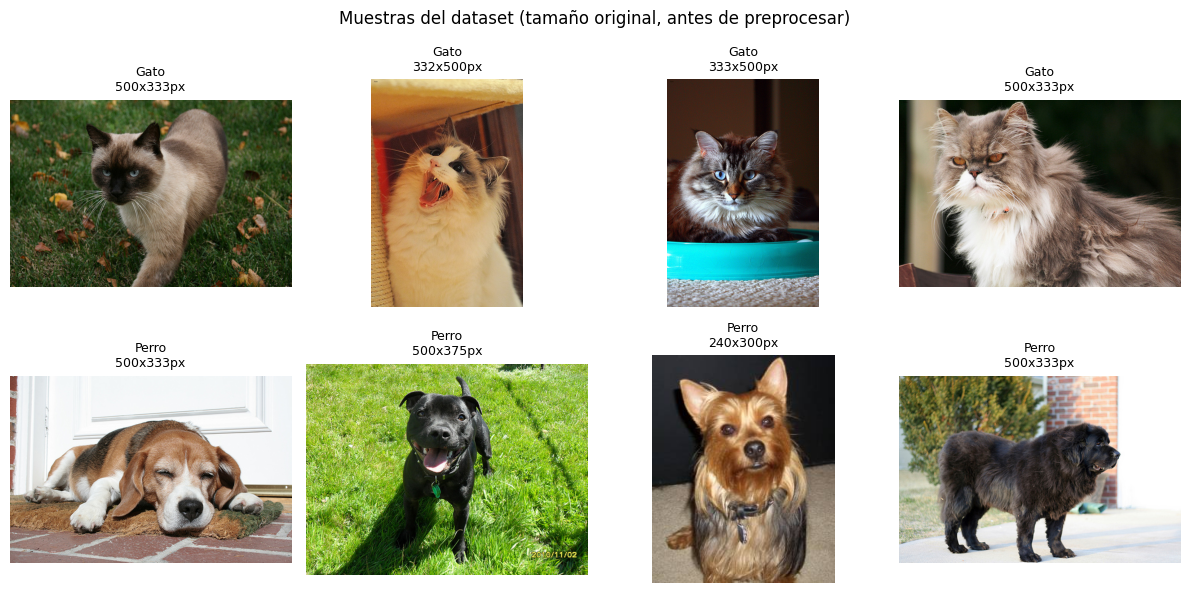

In [3]:
import matplotlib.pyplot as plt

def mostrar_muestras_dataset(images_dir, gatos_sel, perros_sel, n=4):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for i in range(n):
        img_gato = Image.open(os.path.join(images_dir, gatos_sel[i])).convert('RGB')
        axes[0, i].imshow(img_gato)
        axes[0, i].set_title(f"Gato\n{img_gato.size[0]}x{img_gato.size[1]}px", fontsize=9)
        axes[0, i].axis('off')

        img_perro = Image.open(os.path.join(images_dir, perros_sel[i])).convert('RGB')
        axes[1, i].imshow(img_perro)
        axes[1, i].set_title(f"Perro\n{img_perro.size[0]}x{img_perro.size[1]}px", fontsize=9)
        axes[1, i].axis('off')

    fig.suptitle("Muestras del dataset (tamaño original, antes de preprocesar)", fontsize=12)
    plt.tight_layout()
    plt.savefig(RUTA_IMAGENES_SALIDA / 'eda_muestras_dataset.png', dpi=150, bbox_inches='tight')
    plt.show()

mostrar_muestras_dataset(IMAGES_DIR, gatos_sel, perros_sel, n=4)


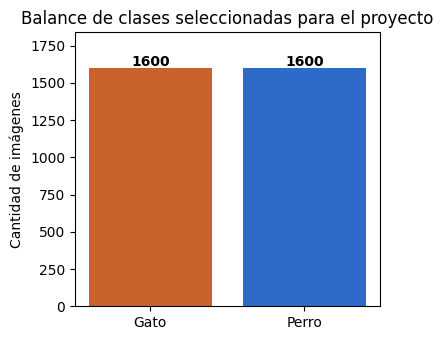

In [4]:
plt.figure(figsize=(4, 3.5))
plt.bar(['Gato', 'Perro'], [len(gatos_sel), len(perros_sel)], color=['#c9622d', '#2d6ac9'])
plt.title('Balance de clases seleccionadas para el proyecto')
plt.ylabel('Cantidad de imágenes')
for i, v in enumerate([len(gatos_sel), len(perros_sel)]):
    plt.text(i, v + 15, str(v), ha='center', fontweight='bold')
plt.ylim(0, max(len(gatos_sel), len(perros_sel)) * 1.15)
plt.tight_layout()
plt.savefig(RUTA_IMAGENES_SALIDA / 'eda_balance_clases.png', dpi=150, bbox_inches='tight')
plt.show()


**Observaciones del análisis exploratorio:**

- Las imágenes originales tienen tamaños distintos entre sí, por lo que se redimensionan a un tamaño fijo antes de entrenar.
- El conjunto quedó perfectamente balanceado (1.600 imágenes por clase).
- Hay bastante variedad de pose, fondo e iluminación entre fotografías, lo que puede dificultar la clasificación (se retoma en el análisis de errores).


## 3. Preparación y preprocesamiento de los datos

In [5]:
def preprocesar_imagen(path, img_size=IMG_SIZE):
    img = Image.open(path).convert('RGB')        # asegura 3 canales
    img = img.resize((img_size, img_size))         # redimensiona a tamaño fijo
    arr = np.array(img, dtype=np.float32) / 255.0  # normaliza a [0,1]
    return arr.flatten()                           # aplana a vector 1D

def construir_dataset(images_dir, gatos_sel, perros_sel):
    X, y = [], []
    for f in gatos_sel:
        X.append(preprocesar_imagen(os.path.join(images_dir, f)))
        y.append(1)  # gato = 1
    for f in perros_sel:
        X.append(preprocesar_imagen(os.path.join(images_dir, f)))
        y.append(0)  # perro = 0
    return np.array(X), np.array(y)

X, y = construir_dataset(IMAGES_DIR, gatos_sel, perros_sel)
print(f"X shape: {X.shape}, y shape: {y.shape}")


X shape: (3200, 12288), y shape: (3200,)


In [6]:
from sklearn.model_selection import train_test_split

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


# --- Normalización estándar (media 0, desviación 1), calculada solo con train ---
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

print("Nueva media:", X_train.mean(), "Nueva std:", X_train.std())


C:\Users\meara\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.sparse import csr_matrix, issparse


Train: (2240, 12288), Val: (480, 12288), Test: (480, 12288)


Nueva media: 1.0217939e-07 Nueva std: 1.0


## 4. Diseño del Perceptrón Multicapa

| Elemento | Decisión | Justificación |
| ------------ | ------------ | ------------ |
| Entrada      | 12.288 neuronas (64×64×3 aplanado)     | Corresponde al vector de píxeles normalizado      |
| Capas ocultas     | 2 capas: 256 neuronas en la primera, 64 en la segunda    | Reducción progresiva típica en MLP; suficiente capacidad sin sobreparametrizar dado el dataset (3.200 imágenes)      |
| Activación capas ocultas | ReLU | Evita el problema de gradiente que se desvanece, estándar en redes profundas |
| Normalización interna | BatchNormalization después de cada capa densa | Estabiliza la distribución de activaciones durante el entrenamiento; fue necesaria porque sin ella, el modelo colapsaba a predecir siempre ~0.5 (ver discusión en la sección de entrenamiento) |
| Capa de salida | 1 neurona, activación sigmoid | Al ser un problema binario, la sigmoide entrega una probabilidad entre 0 y 1 |
| Función de pérdida | binary_crossentropy | Estándar para clasificación binaria con salida sigmoid|
| Optimizador | Adam (learning_rate=0.001) | Convergencia más rápida y estable que SGD plano, buena elección por defecto |
| Regularización | Dropout (0.3) después de cada capa oculta | El input tiene alta dimensionalidad (12.288 features) frente al tamaño del dataset lo que  un alto riesgo de overfitting, confirmado empíricamente durante el entrenamiento |
| Batch size | 32 | Balance entre estabilidad del gradiente y velocidad|
| Épocas | 50 (con Early Stopping, patience=5) | Evita entrenar de más si el modelo ya convergió o empieza a sobreajustar |


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Se fija tambien la semilla de TensorFlow (ademes de random/numpy, ya fijadas mas arriba para que la inicialización de pesos y el orden de los batches
# sean reproducibles de una ejecucion a otra.

tf.random.set_seed(SEED)

# --- Definición de la arquitectura MLP ---
def construir_modelo(input_dim=12288):
    modelo = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return modelo

modelo = construir_modelo()  # pesos nuevos, desde cero
modelo.summary()

In [ ]:
# Detiene el entrenamiento si val_loss no mejora en 5 epocas seguidas, y restaura los pesos de la mejor epoca.
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## 5. Entrenamiento del modelo

In [ ]:
historial = modelo.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


### Discusión: overfitting observado durante el entrenamiento

Durante el entrenamiento, podemos observar claramente un caso de overfittin, donde el accuracy de entrenamiento sube de forma sostenida, mientras que el `val_accuracy` se estanca en un rango mucho más bajo desde las primeras épocas. Manteniendo consistencia, el `val_loss` alcanza un mínimo en una época temprana y luego comienza a subir, mientras que el train_loss sigue disminuyendo.

Esto indica que el modelo está memorizando patrones específicos de las imágenes de entrenamiento en vez de aprender características generales que le permitan clasificar de forma correcta las imágenes nuevas, siendo un comportamiento esperable dado que cada imagen representa como un vector de 12.288 valores (Con alta dimensionalidad) frente a un conjunto de entrenamiento de solo 2.240 imágenes.

#### Mitigación aplicada:

Se configuró `EarlyStopping` con `restore_best_weights=True`, de forma que el modelo final no se queda con los pesos de la última época, si no que con los de la época donde `val_loss` fue mínimo, reportandose como evidencia y limitación del enfoque en la sección de conclusiones y relacionandose directamente con una de las limitaciones estructurales del MLP para clasificación de imágenes (Ver analisis más abajo).

### Curvas de entrenamiento y validación

In [ ]:
def graficar_curvas(historial):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Curva de pérdida
    axes[0].plot(historial.history['loss'], label='Train Loss')
    axes[0].plot(historial.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Evolución de la Función de Pérdida')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Curva de accuracy
    axes[1].plot(historial.history['accuracy'], label='Train Accuracy')
    axes[1].plot(historial.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Evolución de la Precisión')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(RUTA_IMAGENES_SALIDA / 'curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
    plt.show()

graficar_curvas(historial)

### 5.3 Mejorando el modelo: experimentos para subir el accuracy

El diagnóstico anterior nos muestra sobreajuste: el modelo tiene 3,16 millones de parámetros para solo 2.240 imágenes de entrenamiento. 

A partir de eso, se probaron tres ideas simples, cada una entrenando un modelo nuevo y midiéndolo sobre el mismo conjunto de test:

| # | Idea | Hipótesis |
|---|---|---|
| 1 | Más paciencia en Early Stopping (5 → 12) | Quizás el modelo necesitaba más tiempo |
| 2 | Más datos de entrenamiento (1.600 → 2.000/clase) | Más ejemplos, menos margen para memorizar |
| 3 | Espejar imágenes (*data augmentation*) | Duplicar el set de entrenamiento sin fotos nuevas |

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def entrenar_y_evaluar(nombre, X_tr, y_tr, X_v, y_v, X_te, y_te, dropout=0.3, patience=5, epochs=50):
    # Entrena y evalúa una MLP con estos parámetros (se reutiliza en cada experimento).
    tf.random.set_seed(SEED)
    m = models.Sequential([
        layers.Input(shape=(X_tr.shape[1],)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])
    es = callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    h = m.fit(X_tr, y_tr, validation_data=(X_v, y_v), epochs=epochs, batch_size=32, callbacks=[es], verbose=0)

    y_prob = m.predict(X_te, verbose=0)
    y_hat = (y_prob > 0.5).astype(int).flatten()
    r = {
        'experimento': nombre,
        'epocas': len(h.history['loss']),
        'accuracy': accuracy_score(y_te, y_hat),
        'precision': precision_score(y_te, y_hat),
        'recall': recall_score(y_te, y_hat),
        'f1': f1_score(y_te, y_hat),
    }
    print(f"{nombre}")
    print(f"  -> {r['epocas']} épocas | Accuracy={r['accuracy']:.4f}  Precision={r['precision']:.4f}  "
          f"Recall={r['recall']:.4f}  F1={r['f1']:.4f}")
    return m, h, r

y_prob_base = modelo.predict(X_test, verbose=0)
y_hat_base = (y_prob_base > 0.5).astype(int).flatten()

resultados_experimentos = [{
    'experimento': '0. Línea base (dropout=0.3, patience=5, 1.600 img/clase)',
    'epocas': len(historial.history['loss']),
    'accuracy': accuracy_score(y_test, y_hat_base),
    'precision': precision_score(y_test, y_hat_base),
    'recall': recall_score(y_test, y_hat_base),
    'f1': f1_score(y_test, y_hat_base),
}]
print(resultados_experimentos[0]['experimento'])
print(f"  -> {resultados_experimentos[0]['epocas']} épocas | Accuracy={resultados_experimentos[0]['accuracy']:.4f}  "
      f"Precision={resultados_experimentos[0]['precision']:.4f}  Recall={resultados_experimentos[0]['recall']:.4f}  "
      f"F1={resultados_experimentos[0]['f1']:.4f}")


#### Experimento 1 — Más paciencia

La línea base se detuvo en la época 7 (`patience=5`). Probamos `patience=12` para ver si el modelo solo necesitaba más tiempo.

In [ ]:
_, _, r1 = entrenar_y_evaluar(
    '1. Más paciencia (patience=12)',
    X_train, y_train, X_val, y_val, X_test, y_test,
    dropout=0.3, patience=12
)
resultados_experimentos.append(r1)

**Resultado:**<br> El accuracy bajó levemente (57.71% → 56.25%). El modelo ya había llegado a su techo; más tiempo solo permitió más sobreajuste. <br> Se descarta esta idea.